In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import plotly.express as px
from sklearn.linear_model import LinearRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv('/content/global_cancer_patients_2015_2024.csv')

In [ ]:
#Conhecendo o dataset

data.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [ ]:
#Descrição do dataset, com contagem total, média, max, min, etc

data.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [ ]:
#Verificando se há valores nulos, e quais tipos das variáveis

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

Remoção de dados incoerentes

In [ ]:
# Remover inconsistências biológicas nos dados
data = data[
    ~(
        ((data['Gender'] == 'Female') & (data['Cancer_Type'].str.lower() == 'prostate')) |
        ((data['Gender'] == 'Male') & (data['Cancer_Type'].str.lower().str.contains('cervical')))
    )
]


In [ ]:
#Contagem de casos por país

casos_por_pais = data['Country_Region'].value_counts()

pais_mais_casos = casos_por_pais.idxmax()
qtd_mais_casos = casos_por_pais.max()

print(f"O país com mais casos é: {pais_mais_casos} ({qtd_mais_casos} casos)")

O país com mais casos é: Australia (4712 casos)


##Segundo a Sociedade Brasileira de Cancerologia



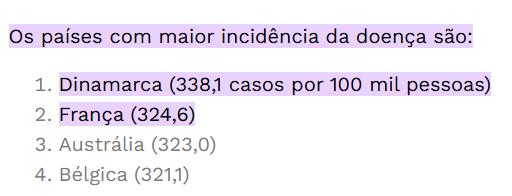

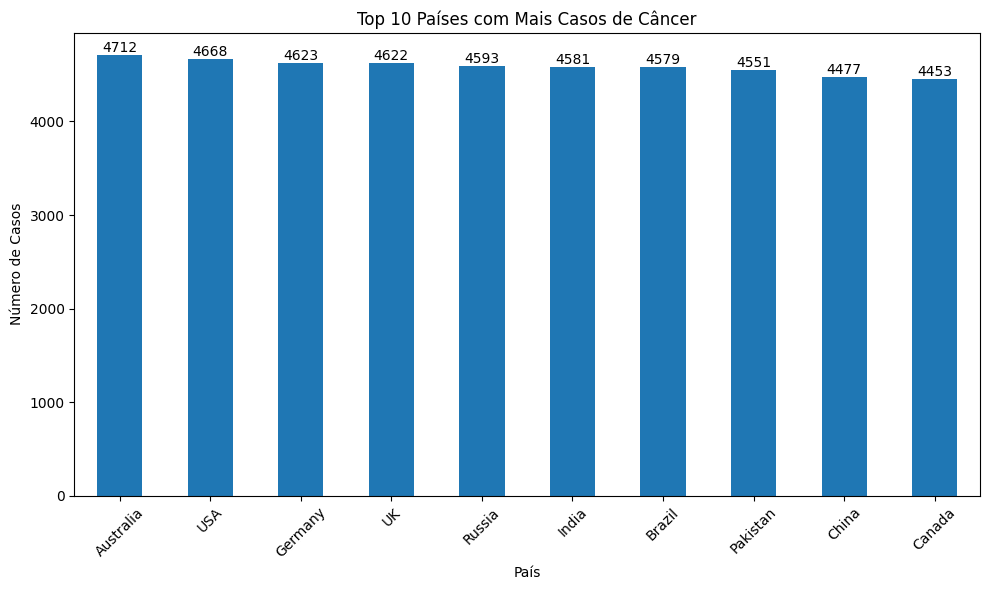

In [ ]:
#Gráfico com a contagem por país

ax = casos_por_pais.head(10).plot(kind='bar', figsize=(10,6), title='Top 10 Países com Mais Casos de Câncer')
plt.xlabel('País')
plt.ylabel('Número de Casos')

# Adicionando rótulos nas barras
for i, v in enumerate(casos_por_pais.head(10)):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
#Filtrando ano de interesse 2015 a 2024

df_filtrado = data[(data['Year'] >= 2015) & (data['Year'] <= 2024)]

In [ ]:
casos_por_ano = df_filtrado['Year'].value_counts().sort_index()

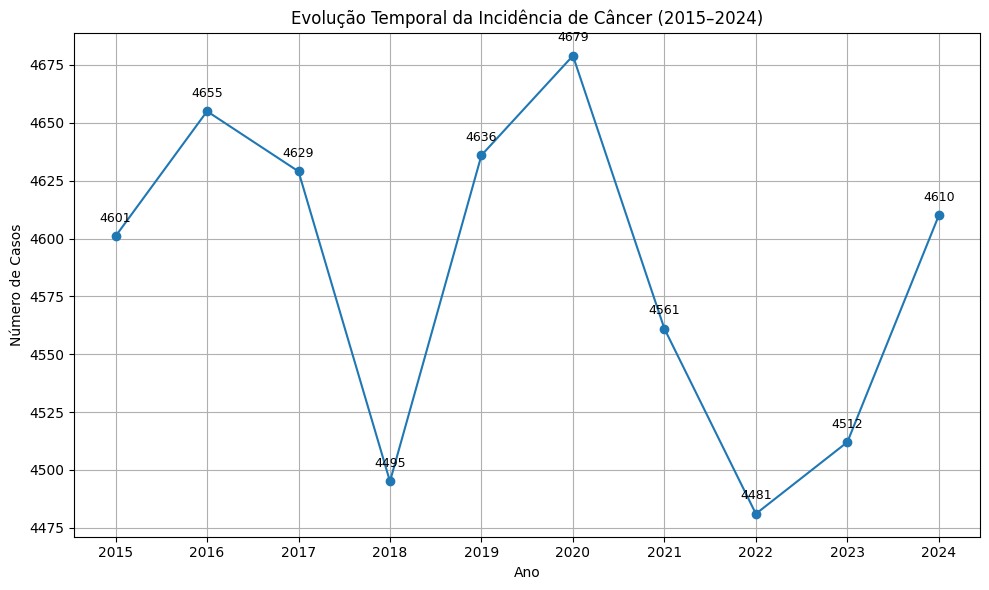

In [ ]:
ax = casos_por_ano.plot(
    kind='line',
    marker='o',
    figsize=(10,6),
    title='Evolução Temporal da Incidência de Câncer (2015–2024)'
)

plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.grid(True)
plt.xticks(range(2015, 2025))
plt.tight_layout()

# Adiciona rótulos em cada ponto da linha
for x, y in casos_por_ano.items():
    ax.text(x, y + 5, str(y), ha='center', va='bottom', fontsize=9)

plt.show()


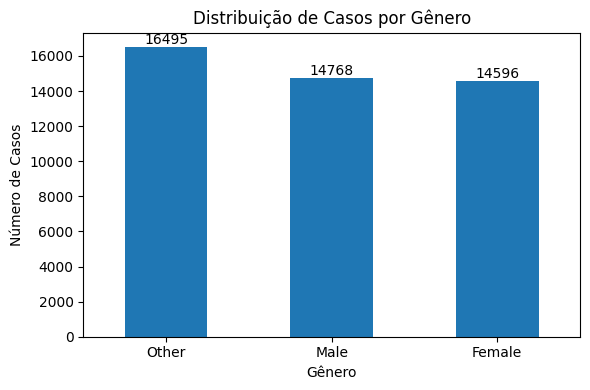

In [ ]:
#Quantidade de casos por genero

casos_por_genero = data['Gender'].value_counts()
ax = casos_por_genero.plot(kind='bar', title='Distribuição de Casos por Gênero', figsize=(6,4))
plt.xlabel('Gênero')
plt.ylabel('Número de Casos')
plt.xticks(rotation=0)
plt.tight_layout()

# Adiciona os rótulos em cima das barras
for i, v in enumerate(casos_por_genero):
    ax.text(i, v + 1, str(v), ha='center', va='bottom')

plt.show()

In [ ]:
#Criando faixas de idade

bins = [0, 18, 30, 45, 60, 75, 100]
labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76+']
data['Faixa_Etaria'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)


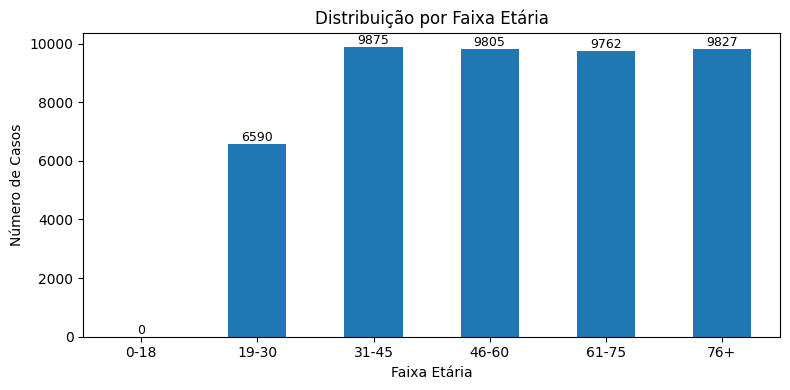

In [ ]:
casos_por_idade = data['Faixa_Etaria'].value_counts().sort_index()
ax = casos_por_idade.plot(kind='bar', title='Distribuição por Faixa Etária', figsize=(8,4))
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Casos')
plt.xticks(rotation=0)
plt.tight_layout()

# Adiciona os rótulos nas barras
for i, v in enumerate(casos_por_idade):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=9)

plt.show()



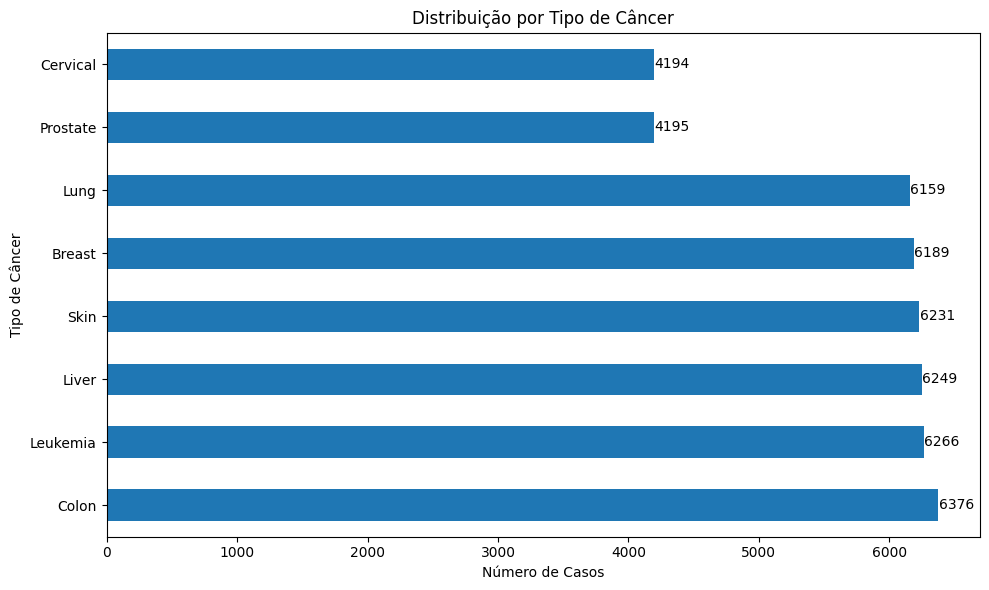

In [ ]:
#Gráfico com o numero de casos por tipo de cancer

casos_por_tipo = data['Cancer_Type'].value_counts()
ax = casos_por_tipo.plot(kind='barh', figsize=(10,6), title='Distribuição por Tipo de Câncer')
plt.xlabel('Número de Casos')
plt.ylabel('Tipo de Câncer')

# Adiciona os rótulos nas barras
for i, v in enumerate(casos_por_tipo):
    ax.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()



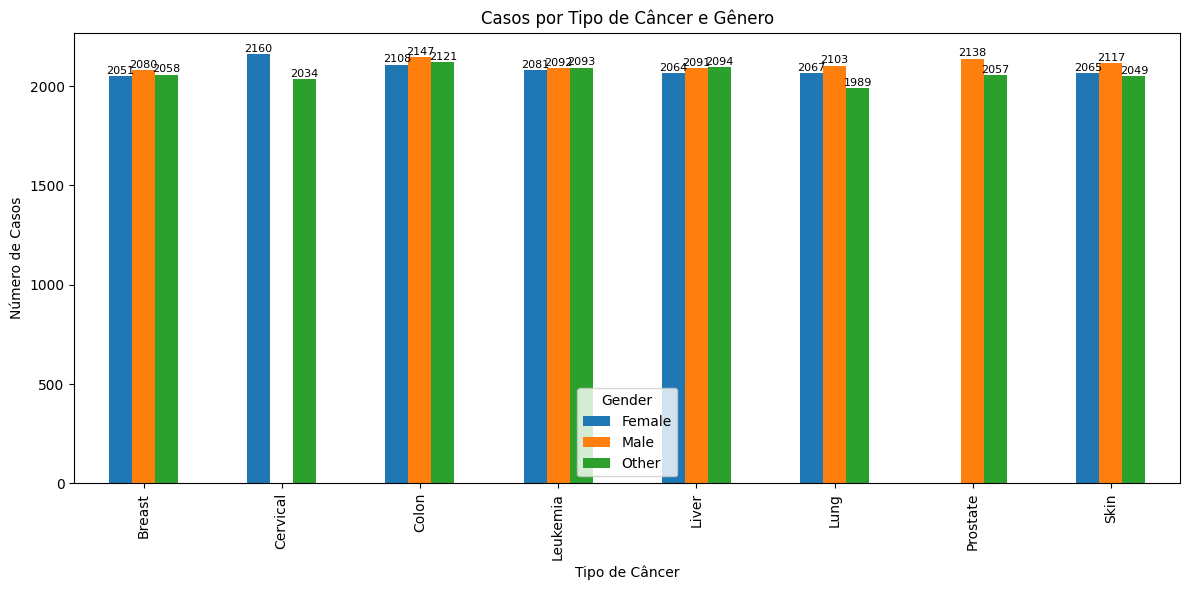

In [ ]:
# Remover casos biologicamente incoerentes
data_filtrada = data[
    ~(
        ((data['Gender'] == 'Female') & (data['Cancer_Type'].str.lower() == 'prostate')) |
        ((data['Gender'] == 'Male') & (data['Cancer_Type'].str.lower().str.contains('cervical')))
    )
]

# Agrupar por gênero e tipo de câncer
genero_tipo = data_filtrada.groupby(['Gender', 'Cancer_Type']).size().unstack().fillna(0)

# Plotar gráfico
ax = genero_tipo.T.plot(kind='bar', figsize=(12,6), title='Casos por Tipo de Câncer e Gênero')
plt.ylabel('Número de Casos')
plt.xlabel('Tipo de Câncer')
plt.tight_layout()

# Adicionar rótulos nas barras
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=8
        )

plt.show()


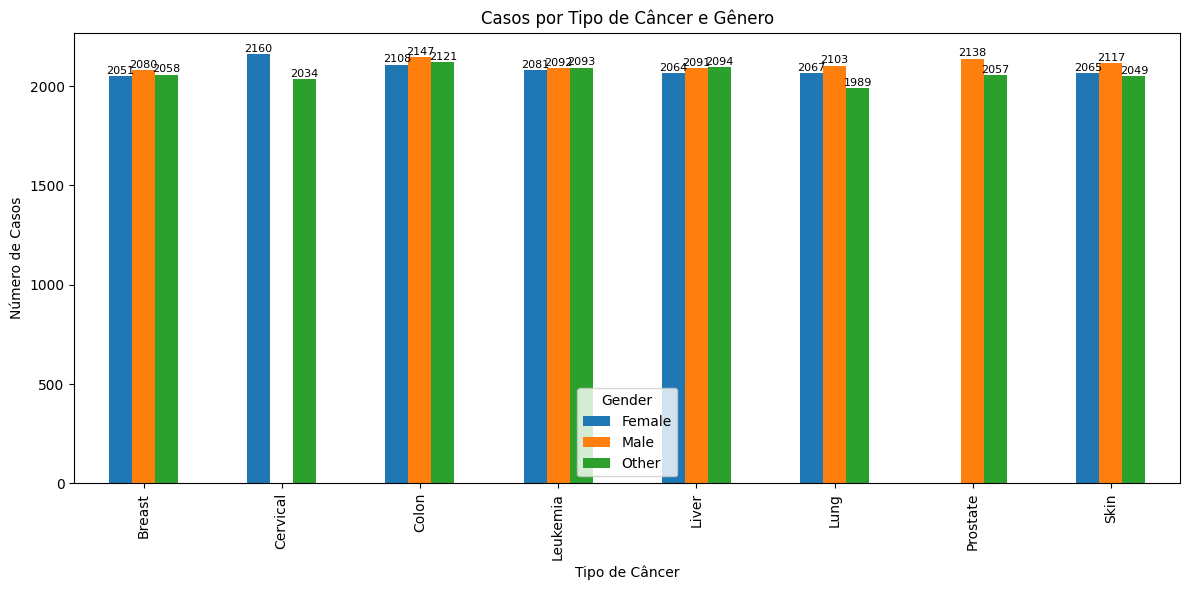

In [ ]:
#Gráfico por genero e tipo de cancer

genero_tipo = data.groupby(['Gender', 'Cancer_Type']).size().unstack().fillna(0)
ax = genero_tipo.T.plot(kind='bar', figsize=(12,6), title='Casos por Tipo de Câncer e Gênero')
plt.ylabel('Número de Casos')
plt.xlabel('Tipo de Câncer')
plt.tight_layout()

# Adiciona rótulos em cada barra
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,  # posição x central da barra
            height + 1,                       # levemente acima da barra
            f'{int(height)}',                 # valor como texto
            ha='center', va='bottom', fontsize=8
        )

plt.show()



##Segundo o INCA

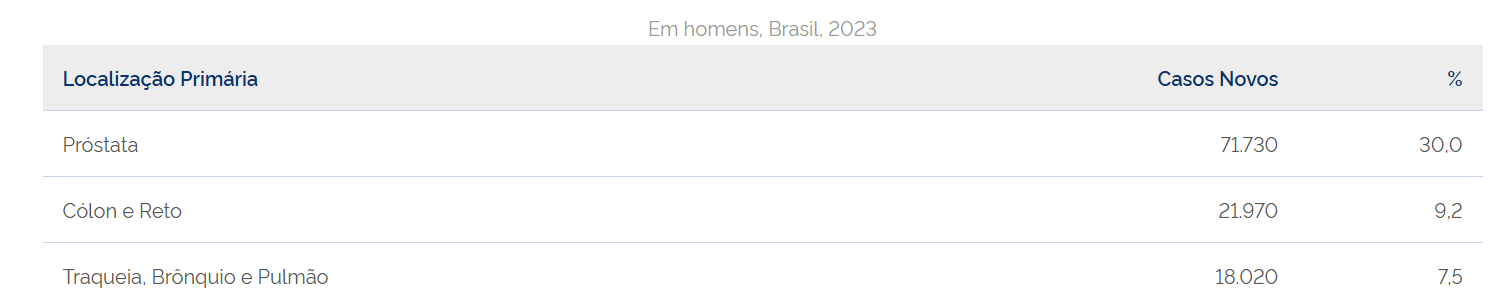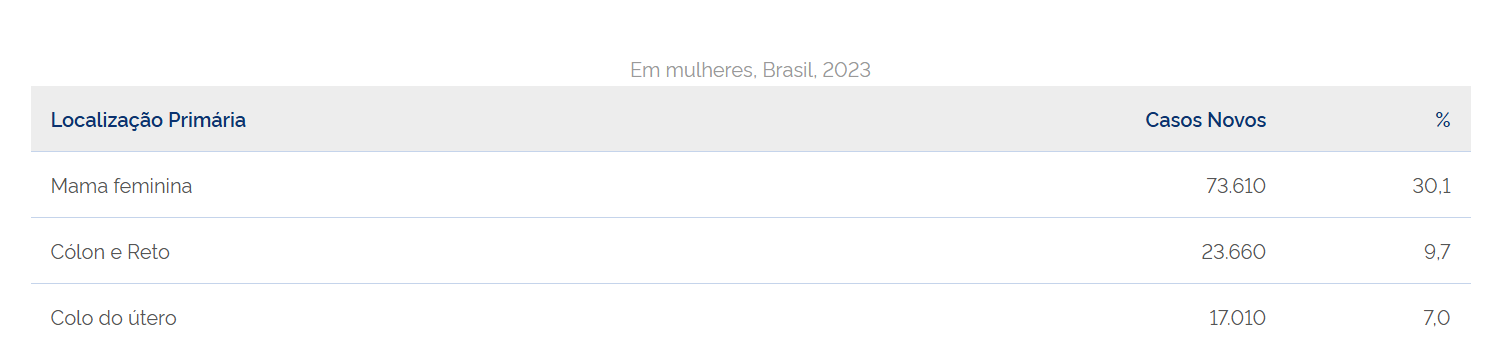

#Segundo a OMS, Os casos mais comuns em 2020 (em termos de novos casos de câncer) foram:

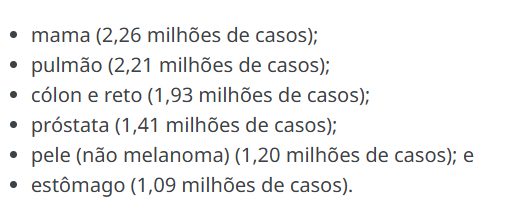

Outliers:

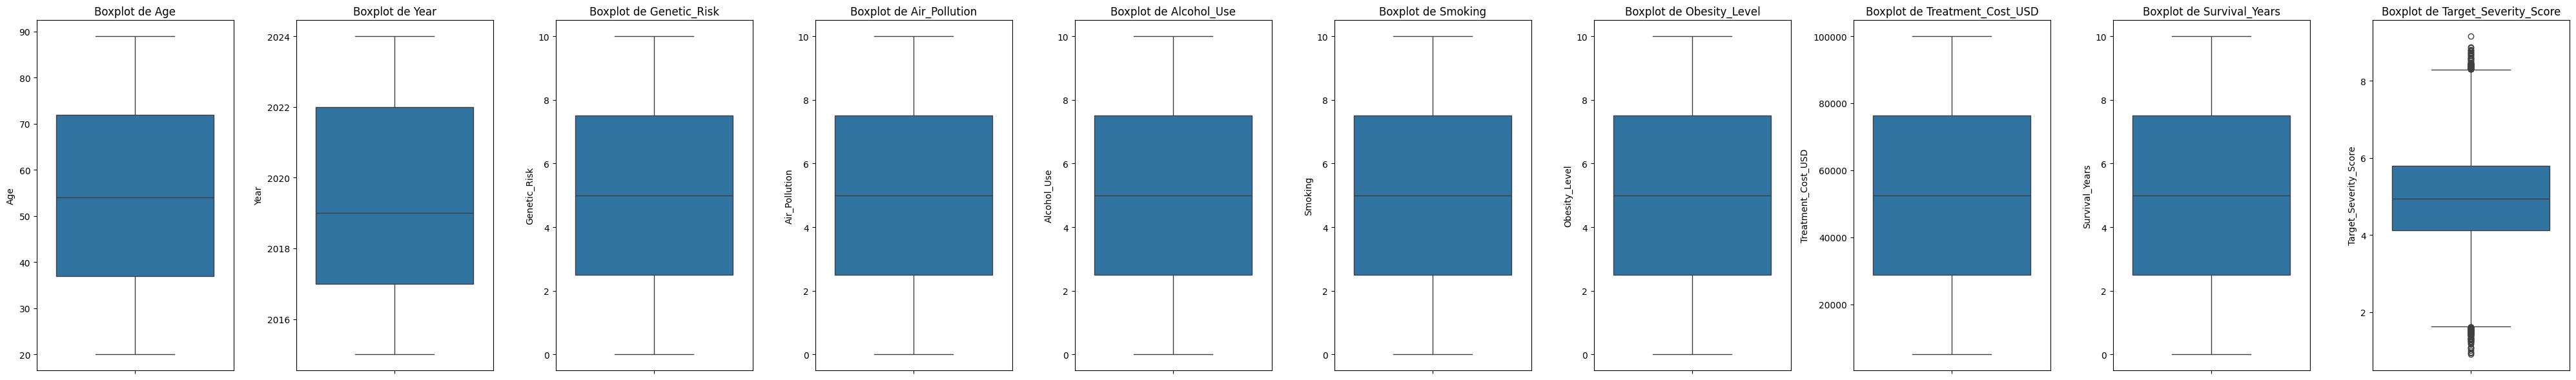

In [ ]:
# Seleciona as colunas numéricas
num_cols = data.select_dtypes(include=['number']).columns

# Define o tamanho da figura para acomodar todos os boxplots
plt.figure(figsize=(len(num_cols)*4, 6))

# Cria um boxplot para cada coluna numérica em subplots
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()

plt.show()

In [ ]:
# Selecionar colunas numéricas
num_cols = ['Age', 'Treatment_Cost_USD', 'Survival_Years']
z_scores = data[num_cols].apply(zscore)

# Filtra linhas com pelo menos um z-score acima de 3 ou abaixo de -3
outliers = data[(abs(z_scores) > 3).any(axis=1)]

print(f"Número de possíveis outliers: {len(outliers)}")


Número de possíveis outliers: 0


In [ ]:
# Agrupar dados por país e ano (contagem de casos)
incidencia = data.groupby(['Country_Region', 'Year']).size().reset_index(name='Casos')

In [ ]:
fig = px.choropleth(
    incidencia,
    locations='Country_Region',       # nome dos países
    locationmode='country names',     # usa nomes reconhecidos
    color='Casos',                    # valor para coloração
    hover_name='Country_Region',      # texto no hover
    animation_frame='Year',           # animação por ano
    color_continuous_scale='Reds',   # escala de cor
    title='Incidência de Câncer por País e Ano'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title='Número de Casos')
)

fig.show()


In [ ]:
# Série por país
# Contagem de casos por país e ano
serie_pais = data.groupby(['Country_Region', 'Year']).size().reset_index(name='Casos')
fig_pais = px.line(
    serie_pais,
    x='Year',
    y='Casos',
    color='Country_Region',
    title='Evolução Temporal da Incidência por País'
)

fig_pais.show()


In [ ]:
#Previsão de casos para 2025
#Dados para o modelo
X = casos_por_ano.index.values.reshape(-1, 1)  # anos (2015, 2016, ...)
y = casos_por_ano.values  # número de casos

# Criar e ajustar o modelo
model = LinearRegression()
model.fit(X, y)

# Prever para 2025
ano_futuro = np.array([[2025]])
previsao_2025 = model.predict(ano_futuro)

print(f"Previsão de casos em 2025 (regressão linear): {int(previsao_2025[0])}")


Previsão de casos em 2025 (regressão linear): 4538


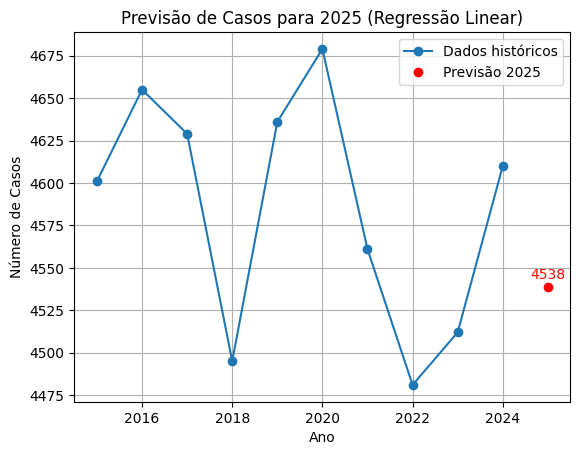

In [ ]:
#Gráfico nos mostrando essa previsão
plt.plot(X.flatten(), y, marker='o', label='Dados históricos')
plt.plot(2025, previsao_2025, 'ro', label='Previsão 2025')

# Adiciona rótulo com o valor da previsão
plt.text(2025, previsao_2025 + 5, f'{int(previsao_2025[0])}', color='red', ha='center')

plt.title('Previsão de Casos para 2025 (Regressão Linear)')
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Tipos de cancer e genero

contingencia = pd.crosstab(data['Cancer_Type'], data['Gender'])
print(contingencia)


Gender       Female  Male  Other
Cancer_Type                     
Breast         2051  2080   2058
Cervical       2160     0   2034
Colon          2108  2147   2121
Leukemia       2081  2092   2093
Liver          2064  2091   2094
Lung           2067  2103   1989
Prostate          0  2138   2057
Skin           2065  2117   2049


In [ ]:
#Esse teste verifica se existe associação entre duas variáveis categóricas (tipo de câncer e gênero)

chi2, p, dof, expected = chi2_contingency(contingencia)

print(f'Estatística qui-quadrado: {chi2:.4f}')
print(f'Valor p: {p:.4f}')


Estatística qui-quadrado: 4173.1149
Valor p: 0.0000


O P-valor é maior que 0.05, ou seja, não podemos rejeitar a hipótese nula. Não há diferença significativa entre tipos de câncer e genero

In [ ]:
# Binarizar obesidade e poluição para facilitar interpretação
data['Obesity_bin'] = (data['Obesity_Level'] > 2).astype(int)
data['AirPoll_bin'] = (data['Air_Pollution'] > 50).astype(int)

# Criar Score de Risco (0 a 3)
data['Risk_Score'] = data['Smoking'] + data['Obesity_bin'] + data['AirPoll_bin']


/tmp/ipython-input-109-3937758718.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




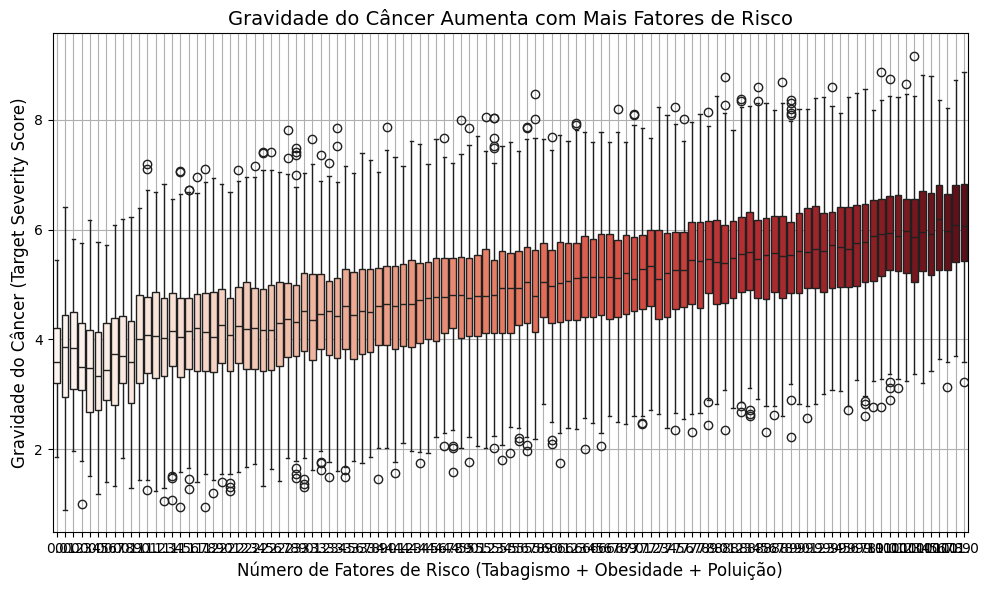

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Risk_Score', y='Target_Severity_Score', data=data, palette='Reds')

plt.title('Gravidade do Câncer Aumenta com Mais Fatores de Risco', fontsize=14)
plt.xlabel('Número de Fatores de Risco (Tabagismo + Obesidade + Poluição)', fontsize=12)
plt.ylabel('Gravidade do Câncer (Target Severity Score)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

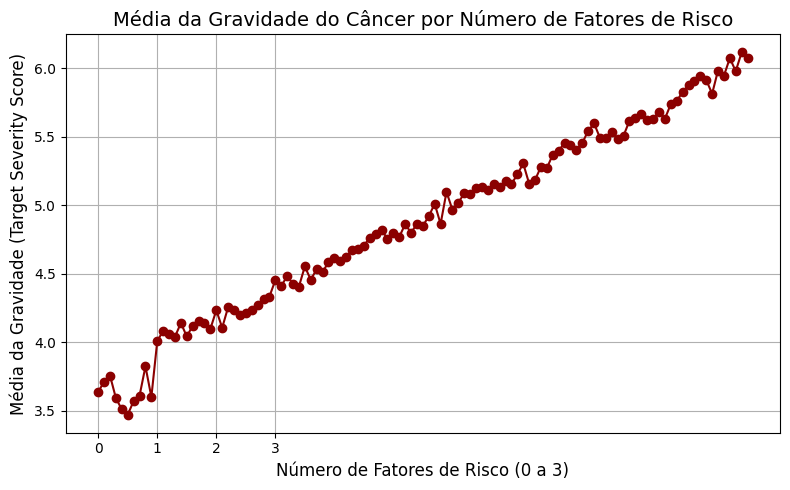

In [ ]:
#Evolução da média da gravidade com o risco

media_gravidade = data.groupby('Risk_Score')['Target_Severity_Score'].mean()

plt.figure(figsize=(8,5))
media_gravidade.plot(marker='o', linestyle='-', color='darkred')

plt.title('Média da Gravidade do Câncer por Número de Fatores de Risco', fontsize=14)
plt.xlabel('Número de Fatores de Risco (0 a 3)', fontsize=12)
plt.ylabel('Média da Gravidade (Target Severity Score)', fontsize=12)
plt.grid(True)
plt.xticks([0,1,2,3])
plt.tight_layout()
plt.show()


In [ ]:
#Modelo de previsão para o nível de gravidade do câncer

In [ ]:
# Selecionar as variáveis que vamos usar
features = ['Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
target = 'Target_Severity_Score'

# Separar os dados em variáveis X (entrada) e y (saída)
X = data[features]
y = data[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Fazer previsões nos dados de teste
y_pred = modelo.predict(X_test)


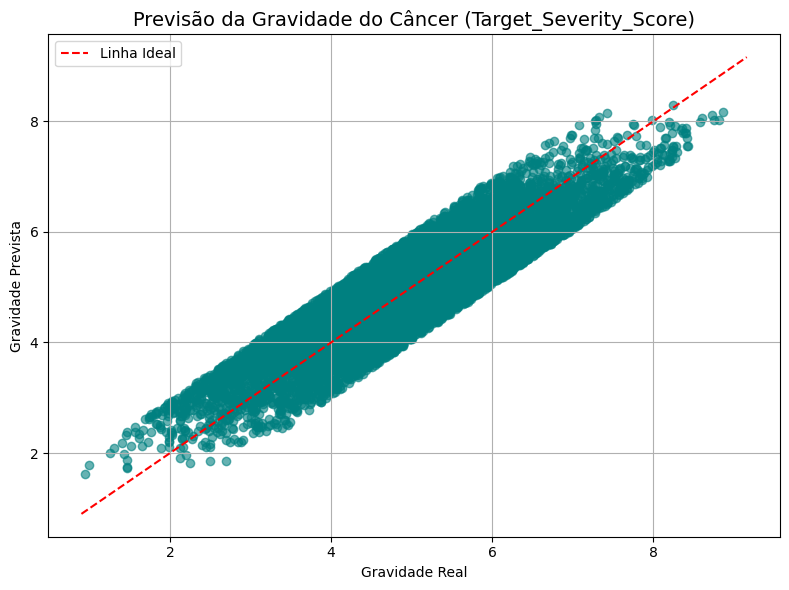

In [ ]:
# Gráfico de comparação: valores reais vs. previstos
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Linha Ideal')
plt.xlabel('Gravidade Real')
plt.ylabel('Gravidade Prevista')
plt.title('Previsão da Gravidade do Câncer (Target_Severity_Score)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Mostrar a performance do modelo
print("Desempenho do Modelo:")
print(f"Erro Quadrático Médio (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coeficiente de Determinação (R²): {r2_score(y_test, y_pred):.2f}")


Desempenho do Modelo:
Erro Quadrático Médio (MSE): 0.30
Coeficiente de Determinação (R²): 0.79


Esse valor mede o erro médio entre o valor real e o valor previsto pelo modelo.
O erro médio esta relativamente baixo, ou seja, esta prevendo bem a gravidade.
0.78 significa que 78% da variação na gravidade do câncer pode ser explicada por esses fatores. (Tabagismo, Obesidade, Genética)

In [ ]:
coeficientes = pd.DataFrame({
    'Fator': features,
    'Peso (importância)': modelo.coef_
}).sort_values(by='Peso (importância)', ascending=False)

print("Importância dos fatores no nível de gravidade:")
print(coeficientes)


Importância dos fatores no nível de gravidade:
           Fator  Peso (importância)
3        Smoking            0.201810
0   Genetic_Risk            0.199971
1  Air_Pollution            0.151383
2    Alcohol_Use            0.151022
4  Obesity_Level            0.100594


##Segundo a OMS:

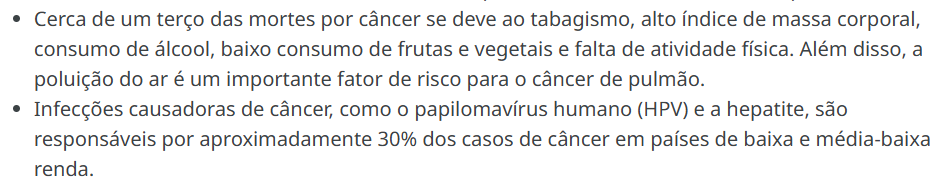

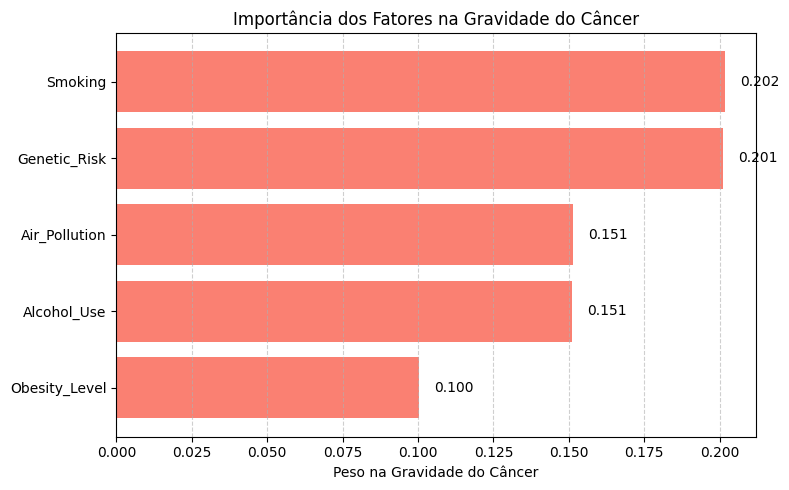

In [ ]:
# Dados de importância (substitua pelos seus se tiver uma variável)
importancia = pd.DataFrame({
    'Fator': ['Smoking', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Obesity_Level'],
    'Importância': [0.201815, 0.201209, 0.151305, 0.150912, 0.100272]
})

# Ordenar para exibir da maior para menor
importancia = importancia.sort_values(by='Importância', ascending=True)

# Plot horizontal
plt.figure(figsize=(8, 5))
plt.barh(importancia['Fator'], importancia['Importância'], color='salmon')
plt.xlabel('Peso na Gravidade do Câncer')
plt.title('Importância dos Fatores na Gravidade do Câncer')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Adicionar rótulos nas barras
for index, value in enumerate(importancia['Importância']):
    plt.text(value + 0.005, index, f'{value:.3f}', va='center')

plt.tight_layout()
plt.show()


#Previsao para 2050

In [ ]:
# Agrupar por ano
casos_por_ano = data.groupby('Year').size().reset_index(name='Numero_de_Casos')

# Definir X (anos) e y (casos)
X = casos_por_ano['Year'].values.reshape(-1, 1)
y = casos_por_ano['Numero_de_Casos'].values

In [ ]:
# Criar e treinar modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [ ]:
# Fazer a previsão
ano_prever = np.array([[2050]])
previsao_2050 = modelo.predict(ano_prever)[0]

print(f"Previsão de casos em 2050: {previsao_2050:.0f}")

Previsão de casos em 2050: 4324


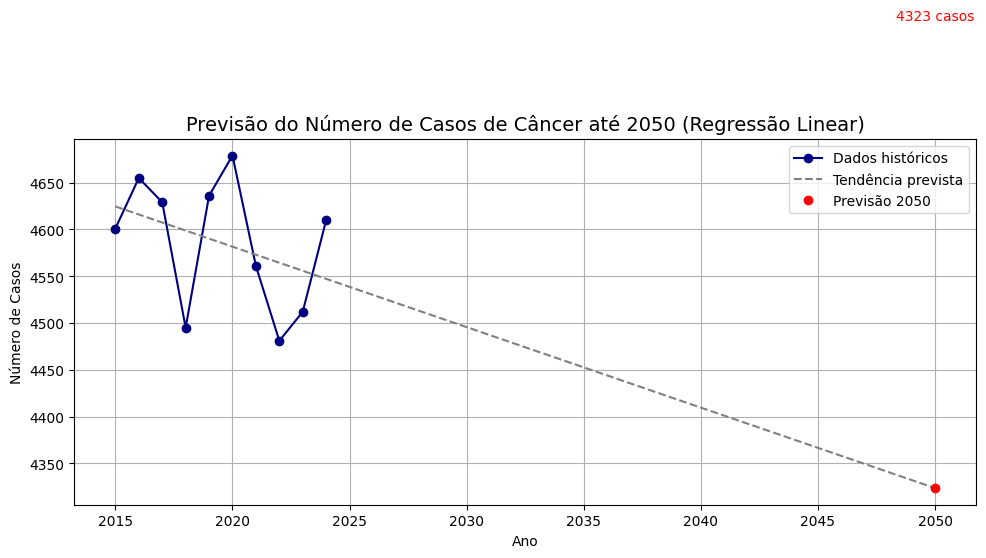

In [ ]:
# Gerar pontos de previsão entre 2015 e 2050
anos_futuros = np.arange(2015, 2051).reshape(-1, 1)
previsoes = modelo.predict(anos_futuros)

# Plotar
plt.figure(figsize=(10, 6))
plt.plot(X.flatten(), y, 'o-', label='Dados históricos', color='navy')
plt.plot(anos_futuros, previsoes, '--', color='gray', label='Tendência prevista')
plt.plot(2050, previsao_2050, 'ro', label='Previsão 2050')

# Rótulo no ponto de 2050
plt.text(2050, previsao_2050 + 500, f'{int(previsao_2050)} casos', color='red', ha='center')

plt.title('Previsão do Número de Casos de Câncer até 2050 (Regressão Linear)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##Segundo a OMS


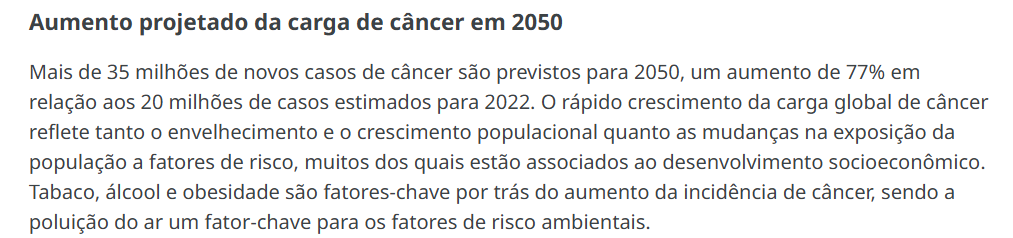